In [0]:
# ============================================================
# CELDA 0: Verificar entorno en Databricks (Versión Serverless)
# ============================================================
import sys

print(f"Spark version: {spark.version}")
print(f"Python version: {sys.version.split()[0]}")
print("✅ Entorno de Databricks listo para TaxiApp Lima")

Spark version: 4.1.0
Python version: 3.12.3
✅ Entorno de Databricks listo para TaxiApp Lima


In [0]:
# ============================================================
# CELDA 1: Dataset de 10,000 viajes TaxiApp Lima
# ============================================================
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import *

np.random.seed(2026)
N = 10_000

distritos = [
    "Miraflores", "San Isidro", "Barranco", "Surco", "San Borja",
    "SJL",        "Comas",      "Los Olivos","Ate",   "Villa El Salvador",
    "Callao",     "Independencia","La Victoria","Pueblo Libre","Jesús María"
]
turnos   = ["mañana", "tarde", "noche", "madrugada"]
metodos  = ["efectivo", "yape",   "tarjeta",  "contra_app"]
estados  = ["completado","completado","completado","cancelado","incidente"]

data = {
    "id_viaje":      [f"TX{i:07d}" for i in range(1, N+1)],
    "fecha":         pd.date_range("2025-09-01", periods=N, freq="1h")
                        .strftime("%Y-%m-%d").tolist(),
    "turno":         np.random.choice(turnos,    N, p=[.30, .35, .25, .10]).tolist(),
    "origen":        np.random.choice(distritos, N).tolist(),
    "destino":       np.random.choice(distritos, N).tolist(),
    "distancia_km":  np.round(np.random.exponential(9, N).clip(1, 45), 2).tolist(),
    "duracion_min":  np.random.randint(5, 120, N).tolist(),
    "tarifa_soles":  np.round(np.random.uniform(7, 95, N), 2).tolist(),
    "propina_soles": np.round(np.random.choice(
                        [0, 0, 0, 2, 5, 10], N, p=[.5, .1, .1, .15, .1, .05]), 2).tolist(),
    "metodo_pago":   np.random.choice(metodos, N, p=[.25, .40, .25, .10]).tolist(),
    "id_conductor":  [f"CON{np.random.randint(1, 200):04d}" for _ in range(N)],
    "rating":        np.round(np.random.normal(4.15, 0.55, N).clip(1, 5), 1).tolist(),
    "estado":        np.random.choice(estados, N, p=[.78, .07, .03, .10, .02]).tolist(),
}

schema = StructType([
    StructField("id_viaje",     StringType()),
    StructField("fecha",        StringType()),
    StructField("turno",        StringType()),
    StructField("origen",       StringType()),
    StructField("destino",      StringType()),
    StructField("distancia_km", DoubleType()),
    StructField("duracion_min", IntegerType()),
    StructField("tarifa_soles", DoubleType()),
    StructField("propina_soles",DoubleType()),
    StructField("metodo_pago",  StringType()),
    StructField("id_conductor", StringType()),
    StructField("rating",       DoubleType()),
    StructField("estado",       StringType()),
])

records = list(zip(*data.values()))
df_bronze = spark.createDataFrame(records, schema)

# --- Escritura en Volume de Unity Catalog (reemplaza a DBFS, que está deshabilitado) ---
spark.sql("CREATE SCHEMA IF NOT EXISTS workspace.taxi_lima")
spark.sql("CREATE VOLUME IF NOT EXISTS workspace.taxi_lima.bronze")

ruta_final = "/Volumes/workspace/taxi_lima/bronze/viajes"

dbutils.fs.rm(ruta_final, recurse=True)   # limpia si ya existía algo ahí
df_bronze.write.mode("overwrite").parquet(ruta_final)

print(f"✅ Bronze layer: {df_bronze.count():,} viajes guardados")
print(f"   Columnas: {len(df_bronze.columns)}")
print(f"   Ruta final (Volume): {ruta_final}")
df_bronze.show(5)
df_bronze.printSchema()

✅ Bronze layer: 10,000 viajes guardados
   Columnas: 13
   Ruta final (Volume): /Volumes/workspace/taxi_lima/bronze/viajes
+---------+----------+---------+------------+-----------+------------+------------+------------+-------------+-----------+------------+------+----------+
| id_viaje|     fecha|    turno|      origen|    destino|distancia_km|duracion_min|tarifa_soles|propina_soles|metodo_pago|id_conductor|rating|    estado|
+---------+----------+---------+------------+-----------+------------+------------+------------+-------------+-----------+------------+------+----------+
|TX0000001|2025-09-01|   mañana|  Los Olivos|        SJL|       16.95|          59|       44.81|          0.0| contra_app|     CON0066|   4.2|completado|
|TX0000002|2025-09-01|    tarde|Pueblo Libre|Jesús María|         1.0|          54|       44.99|          0.0|       yape|     CON0155|   3.6|completado|
|TX0000003|2025-09-01|madrugada| La Victoria|   Barranco|        2.88|          44|       68.18|          0

In [0]:
# ============================================================
# CELDA 2: Exploración inicial — conocer los datos antes de limpiar
# ============================================================
df = spark.read.parquet("/Volumes/workspace/taxi_lima/bronze/viajes")

# Estadísticas básicas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.select("distancia_km", "duracion_min", "tarifa_soles", "propina_soles", "rating") \
  .describe() \
  .show()

# Distribución por estado
print("=== DISTRIBUCIÓN POR ESTADO ===")
df.groupBy("estado").count() \
  .orderBy("count", ascending=False) \
  .withColumn("porcentaje", F.round(F.col("count") / df.count() * 100, 1)) \
  .show()

# Distribución por turno
print("=== DISTRIBUCIÓN POR TURNO ===")
df.groupBy("turno").count().orderBy("count", ascending=False).show()

=== ESTADÍSTICAS DESCRIPTIVAS ===
+-------+-----------------+-----------------+------------------+------------------+------------------+
|summary|     distancia_km|     duracion_min|      tarifa_soles|     propina_soles|            rating|
+-------+-----------------+-----------------+------------------+------------------+------------------+
|  count|            10000|            10000|             10000|             10000|             10000|
|   mean|8.913065999999995|          62.1447|51.151650000000025|            1.3353| 4.140619999999999|
| stddev| 8.54931278024997|33.51733735099359|25.648813154591068|2.5812284253855533|0.5196085208130149|
|    min|              1.0|                5|              7.01|               0.0|               2.1|
|    max|             45.0|              119|             94.99|              10.0|               5.0|
+-------+-----------------+-----------------+------------------+------------------+------------------+

=== DISTRIBUCIÓN POR ESTADO ===
+-----

In [0]:
# ============================================================
# CELDA 3: Silver — datos limpios y enriquecidos
# ============================================================
df_bronze = spark.read.parquet("/Volumes/workspace/taxi_lima/bronze/viajes")

df_silver = (
    df_bronze
    # Filtro 1: solo viajes completados (excluir cancelados e incidentes)
    .filter(F.col("estado") == "completado")
    
    # Filtro 2: distancia mínima válida (> 0.5 km) y tarifa mínima (> 0)
    .filter((F.col("distancia_km") > 0.5) & (F.col("tarifa_soles") > 0))
    
    # Columna nueva: ingreso total del conductor (tarifa + propina)
    .withColumn("ingreso_total",
        F.round(F.col("tarifa_soles") + F.col("propina_soles"), 2))
    
    # Columna nueva: comisión de TaxiApp (20% de la tarifa, no de la propina)
    .withColumn("comision_taxiapp",
        F.round(F.col("tarifa_soles") * 0.20, 2))
    
    # Columna nueva: ingreso neto del conductor (ingreso_total - comisión)
    .withColumn("ingreso_neto_conductor",
        F.round(F.col("ingreso_total") - F.col("comision_taxiapp"), 2))
    
    # Columna nueva: precio por km (tarifa / distancia)
    .withColumn("precio_por_km",
        F.round(F.col("tarifa_soles") / F.col("distancia_km"), 2))
    
    # Columna nueva: categoría de viaje por distancia
    .withColumn("categoria_viaje",
        F.when(F.col("distancia_km") < 5,  "corto")
         .when(F.col("distancia_km") < 15, "medio")
         .otherwise("largo"))
    
    # Columna nueva: es viaje rentable para el conductor (ingreso_neto > S/30)
    .withColumn("es_rentable",
        F.col("ingreso_neto_conductor") > 30)
)

# --- Escritura en Volume (reemplaza a DBFS, deshabilitado) ---
spark.sql("CREATE VOLUME IF NOT EXISTS workspace.taxi_lima.silver")

ruta_silver = "/Volumes/workspace/taxi_lima/silver/viajes_limpios"
dbutils.fs.rm(ruta_silver, recurse=True)
df_silver.write.mode("overwrite").parquet(ruta_silver)

total_silver = df_silver.count()
total_bronze = df_bronze.count()
print(f"✅ Silver layer: {total_silver:,} viajes válidos")
print(f"   Eliminados: {total_bronze - total_silver:,} ({(total_bronze - total_silver)/total_bronze*100:.1f}%)")

# Verificar nuevas columnas
df_silver.select("id_viaje", "tarifa_soles", "propina_soles", 
                 "ingreso_total", "comision_taxiapp", "ingreso_neto_conductor",
                 "precio_por_km", "categoria_viaje", "es_rentable").show(5)

✅ Silver layer: 8,767 viajes válidos
   Eliminados: 1,233 (12.3%)
+---------+------------+-------------+-------------+----------------+----------------------+-------------+---------------+-----------+
| id_viaje|tarifa_soles|propina_soles|ingreso_total|comision_taxiapp|ingreso_neto_conductor|precio_por_km|categoria_viaje|es_rentable|
+---------+------------+-------------+-------------+----------------+----------------------+-------------+---------------+-----------+
|TX0008751|       33.24|          0.0|        33.24|            6.65|                 26.59|         10.2|          corto|      false|
|TX0008752|       33.94|          0.0|        33.94|            6.79|                 27.15|         7.95|          corto|      false|
|TX0008754|       79.43|          0.0|        79.43|           15.89|                 63.54|         5.59|          medio|       true|
|TX0008755|        16.8|         10.0|         26.8|            3.36|                 23.44|          7.4|          corto|  

In [0]:
# ============================================================
# CELDA 4: Gold — métricas para el dashboard ejecutivo
# ============================================================
df_silver = spark.read.parquet("/Volumes/workspace/taxi_lima/silver/viajes_limpios")
df_silver.createOrReplaceTempView("viajes")

# ── GOLD 1: Top 10 rutas más rentables ────────────────────────
gold_rutas = spark.sql("""
    SELECT 
        CONCAT(origen, ' → ', destino)     AS ruta,
        COUNT(*)                            AS total_viajes,
        ROUND(AVG(tarifa_soles), 2)         AS tarifa_promedio,
        ROUND(AVG(precio_por_km), 2)        AS precio_km_prom,
        ROUND(SUM(comision_taxiapp), 2)     AS ingresos_taxiapp
    FROM viajes
    GROUP BY origen, destino
    HAVING COUNT(*) >= 3
    ORDER BY ingresos_taxiapp DESC
    LIMIT 10
""")

# ── GOLD 2: Conductores estrella ──────────────────────────────
gold_conductores = spark.sql("""
    SELECT
        id_conductor,
        COUNT(*)                                        AS total_viajes,
        ROUND(AVG(rating), 2)                           AS rating_prom,
        ROUND(SUM(ingreso_neto_conductor), 2)           AS ingresos_netos,
        ROUND(AVG(ingreso_neto_conductor), 2)           AS ingreso_prom_viaje,
        SUM(CASE WHEN es_rentable THEN 1 ELSE 0 END)   AS viajes_rentables
    FROM viajes
    GROUP BY id_conductor
    HAVING AVG(rating) > 4.5 AND COUNT(*) > 20
    ORDER BY rating_prom DESC, ingresos_netos DESC
    LIMIT 10
""")

# ── GOLD 3: Ingresos TaxiApp por turno y método de pago ───────
gold_turno_pago = spark.sql("""
    SELECT
        turno,
        metodo_pago,
        COUNT(*)                        AS total_viajes,
        ROUND(SUM(comision_taxiapp), 2) AS ingresos_taxiapp,
        ROUND(AVG(rating), 2)           AS rating_prom
    FROM viajes
    GROUP BY turno, metodo_pago
    ORDER BY ingresos_taxiapp DESC
""")

# --- Guardar en Gold layer (Volume, reemplaza a DBFS) ---
spark.sql("CREATE VOLUME IF NOT EXISTS workspace.taxi_lima.gold")

ruta_gold = "/Volumes/workspace/taxi_lima/gold"
gold_rutas.write.mode("overwrite").parquet(f"{ruta_gold}/top_rutas")
gold_conductores.write.mode("overwrite").parquet(f"{ruta_gold}/conductores_estrella")
gold_turno_pago.write.mode("overwrite").parquet(f"{ruta_gold}/ingresos_turno_pago")

print("📊 TOP 10 RUTAS MÁS RENTABLES PARA TAXIAPP:")
gold_rutas.show(truncate=False)

print("\n⭐ CONDUCTORES ESTRELLA (rating > 4.5, > 20 viajes):")
gold_conductores.show()

print("\n💰 INGRESOS TAXIAPP POR TURNO Y MÉTODO DE PAGO:")
gold_turno_pago.show(20)

📊 TOP 10 RUTAS MÁS RENTABLES PARA TAXIAPP:
+----------------------------+------------+---------------+--------------+----------------+
|ruta                        |total_viajes|tarifa_promedio|precio_km_prom|ingresos_taxiapp|
+----------------------------+------------+---------------+--------------+----------------+
|Surco → Comas               |58          |51.34          |19.9          |595.59          |
|Callao → Independencia      |55          |52.61          |18.27         |578.7           |
|La Victoria → La Victoria   |51          |54.81          |13.87         |559.12          |
|Barranco → Ate              |50          |55.37          |11.74         |553.72          |
|Villa El Salvador → Ate     |59          |46.26          |12.36         |545.8           |
|San Borja → Ate             |49          |55.09          |16.12         |539.86          |
|Pueblo Libre → Callao       |58          |46.09          |15.69         |534.62          |
|Independencia → Pueblo Libre|51     

In [0]:
# ============================================================
# CELDA 5: Dashboard ejecutivo — 3 gráficos
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

gold_rutas = spark.read.parquet("/Volumes/workspace/taxi_lima/gold/top_rutas").toPandas()
gold_turno = spark.read.parquet("/Volumes/workspace/taxi_lima/gold/ingresos_turno_pago").toPandas()
gold_cond  = spark.read.parquet("/Volumes/workspace/taxi_lima/gold/conductores_estrella").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Dashboard Ejecutivo — TaxiApp Perú | Septiembre 2025",
             fontsize=14, fontweight="bold")

# Gráfico 1: Top 10 rutas por ingresos TaxiApp
axes[0].barh(gold_rutas["ruta"].str[:25],
             gold_rutas["ingresos_taxiapp"],
             color=plt.cm.Blues(np.linspace(0.4, 0.9, len(gold_rutas))))
axes[0].set_xlabel("Ingresos TaxiApp (S/)")
axes[0].set_title("Top 10 Rutas — Ingresos TaxiApp")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/{x:,.0f}"))
axes[0].invert_yaxis()

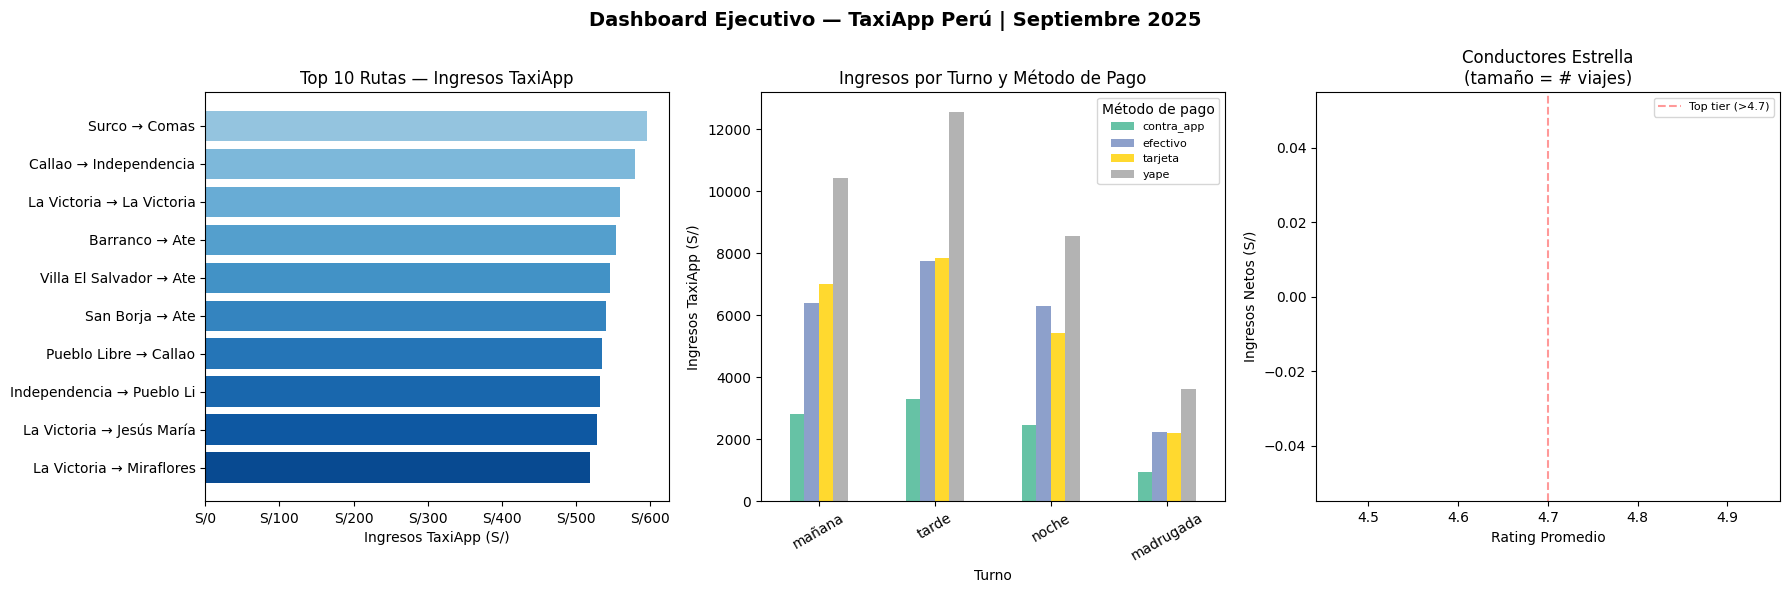

✅ Dashboard guardado


In [0]:
# ============================================================
# CELDA 5: Dashboard ejecutivo — 3 gráficos
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

gold_rutas = spark.read.parquet("/Volumes/workspace/taxi_lima/gold/top_rutas").toPandas()
gold_turno = spark.read.parquet("/Volumes/workspace/taxi_lima/gold/ingresos_turno_pago").toPandas()
gold_cond  = spark.read.parquet("/Volumes/workspace/taxi_lima/gold/conductores_estrella").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Dashboard Ejecutivo — TaxiApp Perú | Septiembre 2025",
             fontsize=14, fontweight="bold")

# Gráfico 1: Top 10 rutas por ingresos TaxiApp
axes[0].barh(gold_rutas["ruta"].str[:25],
             gold_rutas["ingresos_taxiapp"],
             color=plt.cm.Blues(np.linspace(0.4, 0.9, len(gold_rutas))))
axes[0].set_xlabel("Ingresos TaxiApp (S/)")
axes[0].set_title("Top 10 Rutas — Ingresos TaxiApp")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S/{x:,.0f}"))
axes[0].invert_yaxis()

# Gráfico 2: Ingresos por turno (agrupado)
turnos_order = ["mañana", "tarde", "noche", "madrugada"]
turno_pivot  = gold_turno.pivot_table(
    index="turno", columns="metodo_pago",
    values="ingresos_taxiapp", aggfunc="sum", fill_value=0
)
turno_pivot = turno_pivot.reindex([t for t in turnos_order if t in turno_pivot.index])
turno_pivot.plot(kind="bar", ax=axes[1], rot=30, colormap="Set2")
axes[1].set_title("Ingresos por Turno y Método de Pago")
axes[1].set_xlabel("Turno")
axes[1].set_ylabel("Ingresos TaxiApp (S/)")
axes[1].legend(title="Método de pago", fontsize=8)

# Gráfico 3: Conductores estrella — rating vs ingresos
axes[2].scatter(gold_cond["rating_prom"], gold_cond["ingresos_netos"],
                s=gold_cond["total_viajes"] * 2,
                c=gold_cond["rating_prom"], cmap="YlOrRd", alpha=0.8, edgecolors="gray")
for _, row in gold_cond.iterrows():
    axes[2].annotate(row["id_conductor"],
                     (row["rating_prom"], row["ingresos_netos"]),
                     fontsize=7, ha="center", va="bottom")
axes[2].set_xlabel("Rating Promedio")
axes[2].set_ylabel("Ingresos Netos (S/)")
axes[2].set_title("Conductores Estrella\n(tamaño = # viajes)")
axes[2].axvline(x=4.7, color="red", linestyle="--", alpha=0.4, label="Top tier (>4.7)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("/Volumes/workspace/taxi_lima/gold/dashboard_taxiapp.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard guardado")

In [0]:
# ============================================================
# CELDA 6: Structured Streaming — alertas de conductores
# (Adaptado para Serverless: no soporta streaming continuo,
#  se simula con triggers AvailableNow en un loop)
# ============================================================

spark.sql("CREATE VOLUME IF NOT EXISTS workspace.taxi_lima.checkpoints")

stream_source = (
    spark.readStream
    .format("rate")
    .option("rowsPerSecond", 20)
    .load()
)

stream_viajes = (
    stream_source
    .withColumn("id_conductor",
        F.concat(F.lit("CON"),
                 F.lpad((F.col("value") % 200 + 1).cast("string"), 4, "0")))
    .withColumn("rating_simulado",
        F.round(
            F.when(F.col("value") % 15 == 0, F.lit(2.8))
             .otherwise(F.lit(4.0) + (F.col("value") % 10).cast("double") / 20),
            1
        ))
    .withColumn("tarifa_simulada",
        F.round(10 + (F.col("value") % 80).cast("double"), 2))
)

alertas_stream = (
    stream_viajes
    .groupBy(
        F.window(F.col("timestamp"), "30 seconds"),
        F.col("id_conductor")
    )
    .agg(
        F.count("*").alias("viajes_ventana"),
        F.round(F.avg("rating_simulado"), 2).alias("rating_prom_ventana"),
        F.round(F.sum("tarifa_simulada"), 2).alias("facturacion_ventana")
    )
    .filter(F.col("rating_prom_ventana") < 3.5)
    .select(
        F.col("window.start").alias("inicio_ventana"),
        F.col("window.end").alias("fin_ventana"),
        F.col("id_conductor"),
        F.col("viajes_ventana"),
        F.col("rating_prom_ventana"),
        F.col("facturacion_ventana"),
        F.lit("⚠️ ALERTA: Rating bajo — revisar conductor").alias("alerta")
    )
)

import time

print("🔴 SISTEMA DE ALERTAS EN TIEMPO REAL — TaxiApp Perú")
print("   Detectando conductores con rating < 3.5 en ventana de 30 segundos...")
print("   (Serverless: simulado con micro-batches AvailableNow)")
print("-" * 70)

checkpoint_path = "/Volumes/workspace/taxi_lima/checkpoints/alertas_stream"

for ciclo in range(4):
    query_alertas = (
        alertas_stream
        .writeStream
        .format("memory")
        .queryName("alertas_conductores")
        .outputMode("complete")
        .option("checkpointLocation", checkpoint_path)
        .trigger(availableNow=True)
        .start()
    )
    query_alertas.awaitTermination()

    time.sleep(12)

    alertas = spark.sql("""
        SELECT id_conductor, viajes_ventana, rating_prom_ventana, 
               facturacion_ventana, alerta
        FROM alertas_conductores
        ORDER BY rating_prom_ventana ASC
        LIMIT 5
    """)
    if alertas.count() > 0:
        print(f"\n[Ciclo {ciclo+1}/4 — {12*(ciclo+1)} seg]")
        alertas.show(truncate=False)
    else:
        print(f"  [Ciclo {ciclo+1}/4] Sin alertas aún...")

print("\n✅ Stream detenido. Sistema de alertas completado.")

🔴 SISTEMA DE ALERTAS EN TIEMPO REAL — TaxiApp Perú
   Detectando conductores con rating < 3.5 en ventana de 30 segundos...
   (Serverless: simulado con micro-batches AvailableNow)
----------------------------------------------------------------------

[Ciclo 1/4 — 12 seg]
+------------+--------------+-------------------+-------------------+------------------------------------------+
|id_conductor|viajes_ventana|rating_prom_ventana|facturacion_ventana|alerta                                    |
+------------+--------------+-------------------+-------------------+------------------------------------------+
|CON0001     |1             |2.8                |10.0               |⚠️ ALERTA: Rating bajo — revisar conductor|
+------------+--------------+-------------------+-------------------+------------------------------------------+


[Ciclo 2/4 — 24 seg]
+------------+--------------+-------------------+-------------------+------------------------------------------+
|id_conductor|viajes_venta